# import libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Load Data_Set

In [2]:
df=pd.read_csv('spam.csv',encoding='ISO-8859-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['Spam']=df['v1'].apply(lambda x: 1 if x=='spam' else 0) # spam is 1 and ham or not spam  is 0
df.drop(['v1'],axis=1,inplace=True)


In [8]:
df.drop_duplicates()

,v2,Spam
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1
5568,Will Ì_ b going to esplanade fr home?,0
5569,"Pity, * was in mood for that. So...any other s...",0
5570,The guy did some bitching but I acted like i'd...,0


# Splitting

In [10]:
X=df['v2']
y=df['Spam']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Vectorization

In [15]:
vectorize=CountVectorizer()
x_train_count=vectorize.fit_transform(x_train)
x_test_count=vectorize.transform(x_test)

# Model

In [16]:
NB=MultinomialNB()
NB.fit(x_train_count,y_train)


MultinomialNB()

In [21]:
print(NB.score(x_train_count,y_train))
print(NB.score(x_test_count,y_test))


0.9943908458604442
0.9838565022421525


In [22]:
y_pred=NB.predict(x_test_count)

In [28]:
NB.predict(vectorize.transform(['Congratulations! You have won a free ticket to the Bahamas.',' Call now to claim your prize.', 
                                'Hello, how are you?', 'WIN a free ticket now!!!', 'Are we meeting today?',
                                'Claim your prize now!!!']))


array([1, 1, 0, 1, 0, 1])

# Accuracy

In [25]:
print("Classification Report:")
print(classification_report(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



<Axes: >

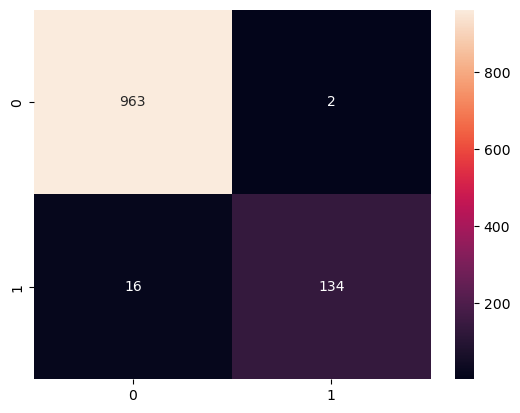

In [31]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

# Saving Model

In [37]:
import pickle
pickle.dump(NB,open('naive_bayes_model.pkl','wb'))
pickle.dump(vectorize,open('vectorizer.pkl','wb'))